<h1>Connectivity of channels</h1>

<h2>One Pair: two electrodes</h2>
First I will plot two electrodes of correlation matrices over time.
    
1) Load matrices in order
2) Extract one pair (i, j)
3) Store values
4) Plot



In [2]:
import os
import mne
import numpy as np
import warnings as w
import matplotlib.pyplot as plt
from scipy.signal import decimate
from elephant.signal_processing import butter

line = "\n❀----------------------------------------------------------❀\n"

<h3>Extract all matrices to memory</h3>

In [3]:
path = "./corr_matrices/"

files = sorted([f for f in os.listdir(path) if f.endswith("npy")])

matrices = []

for file in files:
    matrix = np.load(path + file)
    matrices.append(matrix)
    
print (matrix)
print(len(matrices))



[[ 1.          0.6841382   0.80619709 ... -0.52919897 -0.44434831
  -0.03044085]
 [ 0.6841382   1.          0.59232674 ... -0.40249789 -0.37988244
  -0.01254728]
 [ 0.80619709  0.59232674  1.         ... -0.6665703  -0.49786772
  -0.00646112]
 ...
 [-0.52919897 -0.40249789 -0.6665703  ...  1.          0.63326185
  -0.01163845]
 [-0.44434831 -0.37988244 -0.49786772 ...  0.63326185  1.
   0.05823642]
 [-0.03044085 -0.01254728 -0.00646112 ... -0.01163845  0.05823642
   1.        ]]
591


<h3>Extract one pair (i, j) and store the value</h3>

In [4]:
i = 2
j = 9
values = []
for matrix in matrices:
    values.append(matrix[i, j])
print(values)

[0.06836559637540171, 0.09822983802558888, 0.07526202424699073, 0.05897518692812939, 0.07265763609010886, 0.1528770526426263, 0.10720179627627283, 0.09503036230587575, 0.07703559502673955, 0.05920739460601481, 0.05287827439049265, 0.09292746100926011, 0.10070189445171951, 0.11421101678349825, 0.13409847129997332, 0.14006494447097, 0.1478705890939124, 0.11826266954989227, 0.15986508128824625, 0.1522891008000481, 0.15107037778604473, 0.10030233656072077, 0.10683713190899125, 0.15350568972368953, 0.1648126167178991, 0.12656150291679413, 0.15828338416737917, 0.18240733765005337, 0.14113036625154646, 0.14067818492076933, 0.13618969605435488, 0.17339407440193927, 0.14417573955929064, 0.09840184248760757, 0.02886440681250146, 0.03664266634271525, 0.014673722722140736, 0.03256264540002398, 0.03873098477127212, 0.0353199979165612, 0.04376406285405047, 0.018993371308588396, 0.02853918565789412, -0.016812940473773238, 0.0069589700335307555, 0.020592969577235484, 0.03363257327839307, -0.0003976407

<h3>Plot it</h3>

<function matplotlib.pyplot.show(close=None, block=None)>

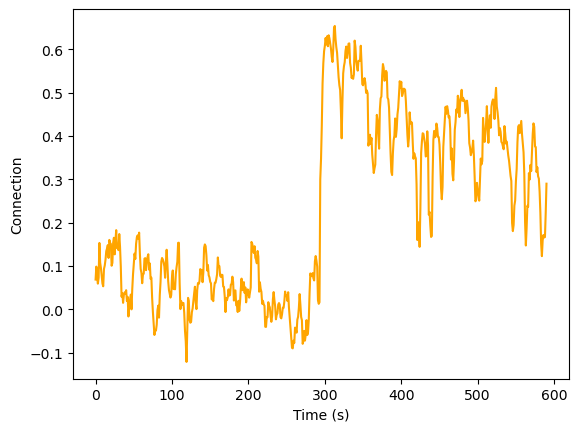

In [5]:
plt.plot(values, color='orange', label= "electrodes")
plt.xlabel('Time (s)')
plt.ylabel('Connection')
plt.show()

This looks like interesting state blocks 

<h1>Connectivity</h1>
<b>Visible confusion what do I need to do ? </b>

I've got connectivity (corelation matrices) for every 10 seconds of data. Which means I know how much are waves similar between two electrodes >> corelation. Hypothesis sounds like this: When brain is bored, the signal is supposed to go down (bored is lower alpha, stronger delta and gamma i think...) in PVS. So I would love to look at change in time first (mean) and second take 2 of every EEG channel and watch their value over time ? Third: I can even make clusters :] 

<b>Im still confused asf so here is workflow 
- Make mean for 2 elecrodes and watch them over time
- Make mean for matrix and watch it over time
- Make cluster and watch it over time
- Explain woman what you did!
- Plot it.

okay, so if I understand. I will compute mean for EVERY corelation matrix I got over time. then I will watch the mean to understand if brain is more synchronised or nah. Then I can even watch some regions (named clusters for some reason, didnt mean the k cluster or some other cluster, I know confusion) but what I can NOT do is to compute mean between two electrodes, because thats something like the corelation i got before. So I can only compute 3 of them electrodes or more. But the mean will only tell us if they react the same (bigger mean = stronger corelation). Nothing about beeing bored "silences" the brain in the results... I think the brain even should be internaly... boreken into sectors (distracted) and the paths are supesed to be shorter, the incula (or wtf the name was) supposed to have less activity and the DNS system more. SO im confused about them: "hodnoty v párech v čase,- zaměření na větší rozdíly,- jeden čtvereček v čase v matici korelace"

<h2> Aitor </h2>
Whenever you calculate the correlation between any two electrodes you are measuring how similar those signals are. If areas interact usually their signal become more similar, even with a small time lag or a phase-locking. Correlation is just the simplest measure of this, but there are many other way to measure how signals depend on each other like the <i> Phase-Locking Value (PLV) or the Granger Causality (GC)</i>, we will use them only if the "simple" correlation shows no effect. 

So assuming that correlation is a good way to measure communication between different areas, the thing we are after is how this communication changes over time. So essentially if we calculate the correlation between two electrodes during the first 5 seconds and during the next 5 seconds if nothing changed between them we should have very similar values (there is always some noise). What Ali saw is that as you keep doing this (the next 5 seconds, the next 5 etc until the end) the correlations systematically go down, suggesting lower communication between brain areas. So the hypothesis is that this lower communication indicates/explains/IS the boredom.

<h3>Now about whether comparing the matrix or the single pair </h3>
The correlation matrix essentially has the correlation value for every pair of electrodes. It is likely that certain pairs of electrodes (certain index in the correlation matrix) change more over time than others. That is what I would expect, there is probably a certain subset of electrode pairs that change more, because those correspond to the brain areas that are most relevant for the boredom. We cannot see the insula in EEG (it's in the middle of the head), but should be able to see the cortical areas that are related to it. 

<b> If you take the average of the entire correlation matrix </b> then you are averaging away all the information about brain areas and looking at the communication in the whole brain. That is fine, seeing changes in the average of the matrix would mean that the changes in communication are widespread. But what can happen is that the average is close to the noise value (maybe some pairs are going up. some others are going down, so on average it stays the same). 

It is worthwhile looking at both things, single pairs (there are 124x123 of them per time point) and the whole average (just one number per time point). 